<a href="https://colab.research.google.com/github/databyhuseyn/MachineLearning/blob/main/Imbalance_Dataset_and_Hyperparameter_Tuning_Sample_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!/bin/bash
!curl -L -o Downloadstelco-customer-churn.zip https://www.kaggle.com/api/v1/datasets/download/blastchar/telco-customer-churn

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  171k  100  171k    0     0   654k      0 --:--:-- --:--:-- --:--:--  654k


In [ ]:
!ls

Downloadstelco-customer-churn.zip  sample_data


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('Downloadstelco-customer-churn.zip')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [ ]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


NA-lar yoxdur, yaaayy!!!

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


IMBALANCE DATASET!!!

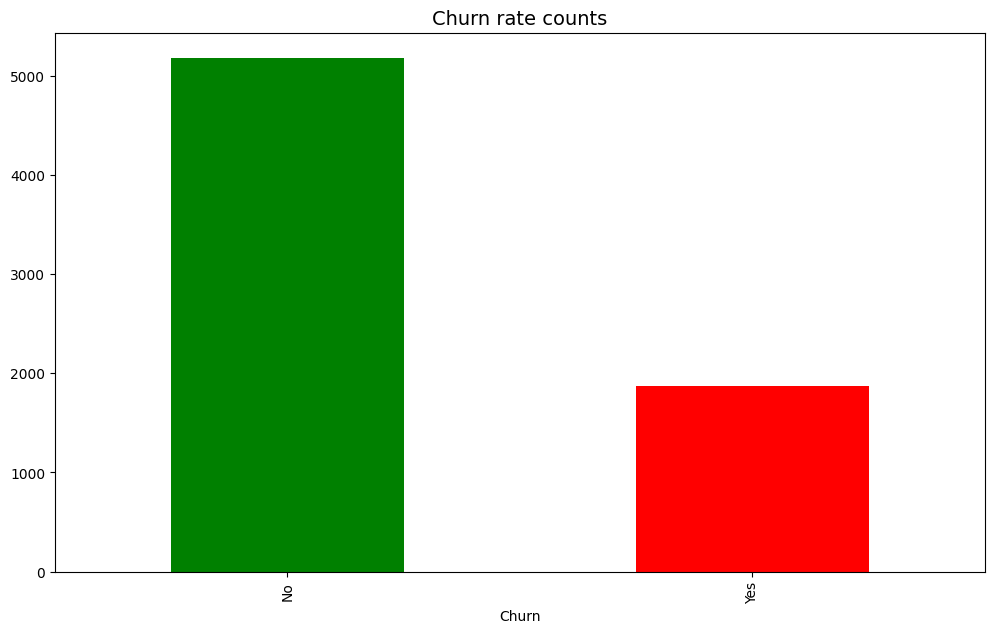

In [ ]:
plt.figure(figsize=(12, 7))
plt.title('Churn rate counts', size=14)
df['Churn'].value_counts().plot(kind='bar', color=['Green', 'Red']);

In [ ]:
if df['Churn'].isna().sum() > 0:
  df.dropna(subset=['Churn'], inplace=True)

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn'].copy()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train_full, X_test, y_train_full, y_test= train_test_split(X, y, test_size=0.2, stratify=y)  # train test split


In [ ]:
X_train, X_val, y_train, y_val= train_test_split(X_train_full, y_train_full, test_size=0.2)  # getting train and validation datasets from X_train_full and y_train_full

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import numpy as np

In [ ]:
# dividing into numeric and categorical features, so we can process the data individually
num_features = X_train.select_dtypes(include=[np.number]).columns
cat_features = X_train.select_dtypes(exclude=[np.number]).columns

In [ ]:
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

transformer = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
], remainder='passthrough')

model = RandomForestClassifier()

full_pipeline = Pipeline([
    ('preprocessing', transformer),
    ('estimator', model)
])

In [ ]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(...e_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('estimator', RandomForestClassifier())])

In [ ]:
print(f'train score: {full_pipeline.score(X_train, y_train)}\nval score: {full_pipeline.score(X_val, y_val)}\ntest score: {full_pipeline.score(X_test, y_test)}')

train score: 0.9982249833592189
val score: 0.80301685891748
test score: 0.7821149751596878


Model Overfitted


In [ ]:
preds = full_pipeline.predict(X_val)
preds

array(['No', 'No', 'No', ..., 'Yes', 'No', 'No'], dtype=object)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_val, preds))

              precision    recall  f1-score   support

          No       0.83      0.92      0.87       831
         Yes       0.68      0.47      0.56       296

    accuracy                           0.80      1127
   macro avg       0.76      0.70      0.71      1127
weighted avg       0.79      0.80      0.79      1127



As we can see, since the dataset is imbalanced, f1 score for class 1 ('YES') is 56% and it is almost as bad as dummy classifier(50%). We need to do Oversampling the minority class or undersampling the majority class. We can drop some of the instances to do undersampling, but since loosing data is not a good idea, I will go on with oversampling from Imbalance Learning library called "imblearn"

# SMOTE / UnderSampling

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm = SMOTE(random_state=42)

In [ ]:
X_train_transformed = transformer.transform(X_train)
X_val_transformed = transformer.transform(X_val)
X_test_transformed = transformer.transform(X_test)

In [ ]:
X_train_oversampled, y_train_oversampled = sm.fit_resample(X_train_transformed, y_train)
X_val_oversampled, y_val_oversampled = sm.fit_resample(X_val_transformed, y_val)
X_test_oversampled, y_test_oversampled = sm.fit_resample(X_test_transformed, y_test)

In [ ]:
model.fit(X_train_oversampled, y_train_oversampled)

RandomForestClassifier()

In [ ]:
print('SCORES AFTER OVERSAMPLING')
print(f'train score: {model.score(X_train_oversampled, y_train_oversampled)}\nval score: {model.score(X_val_oversampled, y_val_oversampled)}\ntest score: {model.score(X_test_oversampled, y_test_oversampled)}')

SCORES AFTER OVERSAMPLING
train score: 0.9989419588875453
val score: 0.8158844765342961
test score: 0.7980676328502415


Now a little bit better, but still overfitted

# HyperParameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    'n_estimators': [50, 60, 70, 80],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split':[2, 5, 10],
    'n_jobs':[-1],
    'max_features':['sqrt', 'log2', None]
}

In [ ]:
rscv = RandomizedSearchCV(model, param_grid, cv=3, n_iter=20)
rscv.fit(X_train_oversampled, y_train_oversampled)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 60, 70, 80],
                                        'n_jobs': [-1]})

In [ ]:
rscv.best_params_

{'n_jobs': -1,
 'n_estimators': 80,
 'min_samples_split': 5,
 'max_features': None,
 'max_depth': 20,
 'criterion': 'gini'}

In [ ]:
rscv.best_score_

np.float64(0.8387365180785723)

In [ ]:
best_model = rscv.best_estimator_

In [ ]:
best_model.fit(X_train_oversampled, y_train_oversampled)

RandomForestClassifier(max_depth=20, max_features=None, min_samples_split=5,
                       n_estimators=80, n_jobs=-1)

In [ ]:
print('SCORES AFTER OVERSAMPLING')
print(f'train score: {best_model.score(X_train_oversampled, y_train_oversampled)}\nval score: {best_model.score(X_val_oversampled, y_val_oversampled)}\ntest score: {best_model.score(X_test_oversampled, y_test_oversampled)}')

SCORES AFTER OVERSAMPLING
train score: 0.9579806529625151
val score: 0.8116726835138387
test score: 0.8082125603864734


Final Results are satisfying, even though there's overfitting, but not so bad

In [ ]:
new_preds = best_model.predict(X_val_oversampled)

In [ ]:
print(classification_report(y_val_oversampled, new_preds))

              precision    recall  f1-score   support

          No       0.78      0.87      0.82       831
         Yes       0.85      0.75      0.80       831

    accuracy                           0.81      1662
   macro avg       0.82      0.81      0.81      1662
weighted avg       0.82      0.81      0.81      1662



The chart above shows 82% f1 sccore for class 0, 80% f1 score for class 1. Thus, the results are really satisfying

# we could do feature selection, but it would take so long, so I didn't do it :D